In [1]:
import pandas as pd
import numpy as np

train_df = pd.read_parquet('../data/UNSW_NB15_training-set.parquet')
test_df  = pd.read_parquet('../data/UNSW_NB15_testing-set.parquet')

print("Attack categories in training set:")
print(train_df['attack_cat'].value_counts())
print()
print("Total categories:", train_df['attack_cat'].nunique())

Attack categories in training set:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Total categories: 10


In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Fresh copies
X_train = train_df.drop(columns=['label', 'attack_cat']).copy()
X_test  = test_df.drop(columns=['label', 'attack_cat']).copy()

# Target is now attack_cat instead of label
y_train = train_df['attack_cat'].copy()
y_test  = test_df['attack_cat'].copy()

# Encode attack_cat labels
le_target = LabelEncoder()
y_train_encoded = le_target.fit_transform(y_train)
y_test_encoded  = le_target.transform(y_test)

print("Classes found:", le_target.classes_)

# Encode categorical feature columns
cat_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

le = LabelEncoder()
for col in cat_cols:
    combined = pd.concat([X_train[col], X_test[col]]).astype(str)
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))

# Convert to float
X_train = X_train.astype(float)
X_test  = X_test.astype(float)

# Scale
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("Preprocessing complete!")
print("X_train shape:", X_train.shape)
print("y_train sample:", y_train_encoded[:5])

Classes found: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']
Preprocessing complete!
X_train shape: (175341, 34)
y_train sample: [6 6 6 6 6]


In [3]:
from xgboost import XGBClassifier

num_classes = len(le_target.classes_)
print(f"Training {num_classes}-class model...")

model_mc = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

model_mc.fit(X_train, y_train_encoded)
print("Training complete!")

Training 10-class model...
Training complete!


In [4]:
from sklearn.metrics import classification_report

y_pred_encoded = model_mc.predict(X_test)

# Convert back to original names
y_pred_labels = le_target.inverse_transform(y_pred_encoded)
y_test_labels = le_target.inverse_transform(y_test_encoded)

print("--- Multiclass Results ---")
print(classification_report(y_test_labels, y_pred_labels))

--- Multiclass Results ---
                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00       677
      Backdoor       0.67      0.05      0.09       583
           DoS       0.54      0.04      0.07      4089
      Exploits       0.57      0.90      0.69     11132
       Fuzzers       0.30      0.59      0.40      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.94      0.76      0.84     37000
Reconnaissance       0.93      0.81      0.86      3496
     Shellcode       0.38      0.58      0.46       378
         Worms       0.56      0.23      0.32        44

      accuracy                           0.77     82332
     macro avg       0.59      0.49      0.47     82332
  weighted avg       0.82      0.77      0.77     82332



In [5]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(model_mc,  '../models/xgboost_multiclass.pkl')
joblib.dump(scaler,    '../models/scaler_multiclass.pkl')
joblib.dump(le_target, '../models/label_encoder_target.pkl')

print("All multiclass models saved!")
print("- models/xgboost_multiclass.pkl")
print("- models/scaler_multiclass.pkl")
print("- models/label_encoder_target.pkl")

All multiclass models saved!
- models/xgboost_multiclass.pkl
- models/scaler_multiclass.pkl
- models/label_encoder_target.pkl


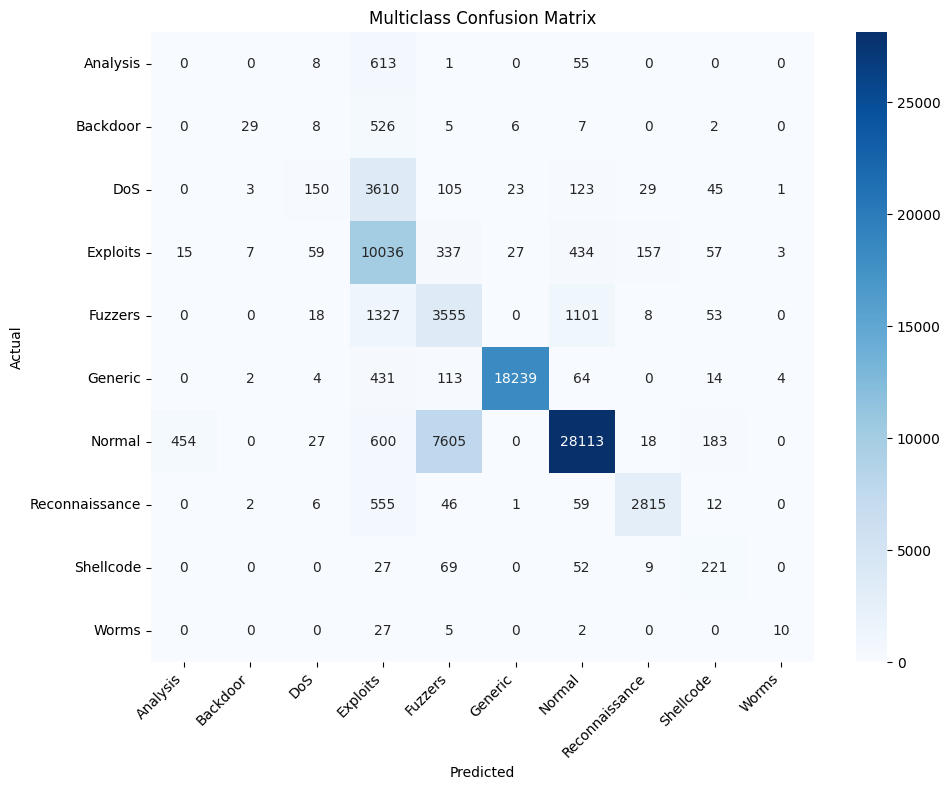

Saved to outputs/confusion_matrix_multiclass.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

classes = le_target.classes_
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.title('Multiclass Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/confusion_matrix_multiclass.png')
plt.show()
print("Saved to outputs/confusion_matrix_multiclass.png")

In [7]:
import plotly.express as px

type_counts = pd.Series(y_pred_labels).value_counts().reset_index()
type_counts.columns = ['Attack Type', 'Count']

fig = px.bar(
    type_counts,
    x='Attack Type',
    y='Count',
    title='Predicted Attack Type Distribution',
    color='Attack Type'
)

# Save as HTML only — skip PNG
fig.write_html('../outputs/attack_distribution.html')
print("Saved to outputs/attack_distribution.html")
print("\nAttack type counts:")
print(type_counts.to_string(index=False))

Saved to outputs/attack_distribution.html

Attack type counts:
   Attack Type  Count
        Normal  30010
       Generic  18296
      Exploits  17752
       Fuzzers  11841
Reconnaissance   3036
     Shellcode    587
      Analysis    469
           DoS    280
      Backdoor     43
         Worms     18


In [8]:
from sklearn.metrics import classification_report

print("=== Per Attack Type Performance ===\n")
print(classification_report(y_test_labels, y_pred_labels))

=== Per Attack Type Performance ===

                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00       677
      Backdoor       0.67      0.05      0.09       583
           DoS       0.54      0.04      0.07      4089
      Exploits       0.57      0.90      0.69     11132
       Fuzzers       0.30      0.59      0.40      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.94      0.76      0.84     37000
Reconnaissance       0.93      0.81      0.86      3496
     Shellcode       0.38      0.58      0.46       378
         Worms       0.56      0.23      0.32        44

      accuracy                           0.77     82332
     macro avg       0.59      0.49      0.47     82332
  weighted avg       0.82      0.77      0.77     82332



In [9]:
from sklearn.utils.class_weight import compute_sample_weight

# Calculate sample weights to balance all classes
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_encoded
)

# Retrain with weights
model_mc_balanced = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

print("Training balanced multiclass model...")
model_mc_balanced.fit(
    X_train, y_train_encoded,
    sample_weight=sample_weights
)
print("Training complete!")

# Evaluate
y_pred_balanced = model_mc_balanced.predict(X_test)
y_pred_balanced_labels = le_target.inverse_transform(y_pred_balanced)

print("\n=== Balanced Multiclass Results ===\n")
print(classification_report(y_test_labels, y_pred_balanced_labels))

Training balanced multiclass model...
Training complete!

=== Balanced Multiclass Results ===

                precision    recall  f1-score   support

      Analysis       0.03      0.12      0.04       677
      Backdoor       0.05      0.49      0.09       583
           DoS       0.32      0.24      0.27      4089
      Exploits       0.83      0.58      0.68     11132
       Fuzzers       0.28      0.71      0.40      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.99      0.60      0.75     37000
Reconnaissance       0.85      0.85      0.85      3496
     Shellcode       0.13      0.98      0.23       378
         Worms       0.47      0.77      0.58        44

      accuracy                           0.68     82332
     macro avg       0.49      0.63      0.49     82332
  weighted avg       0.86      0.68      0.73     82332

